# **🚗 Adfærdsanalyse af Global EV Adoption**

## **Notebook Indhold**

1. **Udforske** datasættet (shape, kolonner, missing værdier)
2. **Visualisere** nøgle mønstre og distribution
3. **Forbehandle** datasættet (håndtere null værdier, omkode kategorier)
4. **Træne** en Random Forest + XGBoost model til at forudsige sandsynligheden for EV-adoption
5. **Evaluate** modellerne med nøjagtighed, klassifikationsrapport og feature importance
6. **Opsummere** med nøgle resultater

> 🎯 **Mål Variable:** `ev_adoption_likelihood` — Low / Medium / High

---

## **📦 Step 1: Installere Biblioteker**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## **📂 Step 2: Indlæs data**

In [ ]:
df = pd.read_csv('global_ev_adoption_behavior_2026.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (50000, 23)

First 5 rows:


,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9


## **🔍 Step 3: Exploratory Data Analysis (EDA)**

Før vi bygger vores model dykker vi ned i vores data. Dette hjælper os med at få et overblik over:
- Hvilke kolonner der findes og deres datatype
- Er der missing værdier?
- Hvordan er fordelingen af mål variablen?

In [3]:
# Basic info
print('📋 Dataset Info:')
print(f'  Rows: {df.shape[0]:,}')
print(f'  Columns: {df.shape[1]}')
print(f'  Missing values: {df.isnull().sum().sum()}')

print('\n📊 Column Types:')
print(df.dtypes)

📋 Dataset Info:
  Rows: 50,000
  Columns: 23
  Missing values: 1500

📊 Column Types:
age                                 int64
annual_income                     float64
education_level                    object
city_type                          object
daily_commute_km                  float64
weekly_travel_distance_km         float64
current_vehicle_type               object
vehicle_age_years                 float64
fuel_expense_per_month            float64
charging_station_accessibility    float64
nearest_charging_station_km       float64
home_charging_available             int64
electricity_cost_per_kwh          float64
environmental_awareness_score     float64
government_incentive_awareness    float64
technology_affinity_score         float64
range_anxiety_score               float64
battery_replacement_concern       float64
ev_knowledge_score                float64
previous_ev_experience              int64
ev_adoption_likelihood             object
monthly_energy_consumption_kwh   

In [ ]:
# Deskriptiv statistik af numeriske kolonner
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,50000.0,45.00,14.11,21.00,33.00,45.00,57.00,69.00
annual_income,50000.0,44311.87,26109.17,5104.00,25617.75,37891.00,56051.25,250000.00
daily_commute_km,50000.0,35.17,14.74,5.00,25.00,35.10,45.20,97.90
weekly_travel_distance_km,50000.0,228.73,101.15,25.00,157.70,224.10,294.50,732.30
vehicle_age_years,50000.0,6.01,2.95,0.00,3.90,6.00,8.00,20.00
fuel_expense_per_month,50000.0,295.17,130.18,-99.70,205.20,294.80,383.00,862.00
charging_station_accessibility,49500.0,5.89,2.15,1.00,4.40,5.90,7.40,10.00
nearest_charging_station_km,50000.0,7.13,4.80,0.50,3.00,6.90,10.70,28.50
home_charging_available,50000.0,0.65,0.48,0.00,0.00,1.00,1.00,1.00
electricity_cost_per_kwh,50000.0,0.22,0.08,0.08,0.15,0.22,0.28,0.35


In [ ]:
# Chicker for missing værdier per kolonne
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('⚠️ Columns with missing values:')
print(missing)

⚠️ Columns with missing values:
education_level                   500
charging_station_accessibility    500
ev_knowledge_score                500
dtype: int64


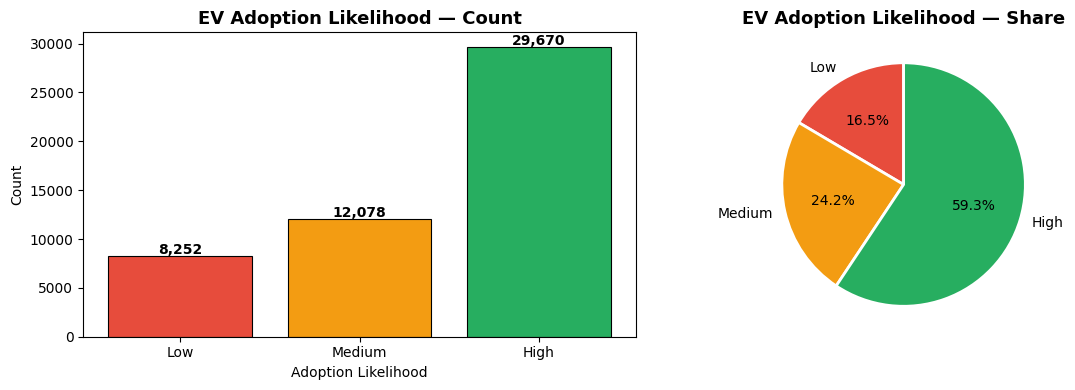

In [ ]:
# Mål variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
order = ['Low', 'Medium', 'High']
colors = ['#e74c3c', '#f39c12', '#27ae60']
counts = df['ev_adoption_sandsynlighed'].value_counts()[order]
axes[0].bar(order, counts, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('EV Adoption Sandsynlighed — Antal', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Adoption Sandsynlighed')
axes[0].set_ylabel('Antal')
for i, v in enumerate(counts):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=order, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('EV Adoption Sandsynlighed — Andel', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

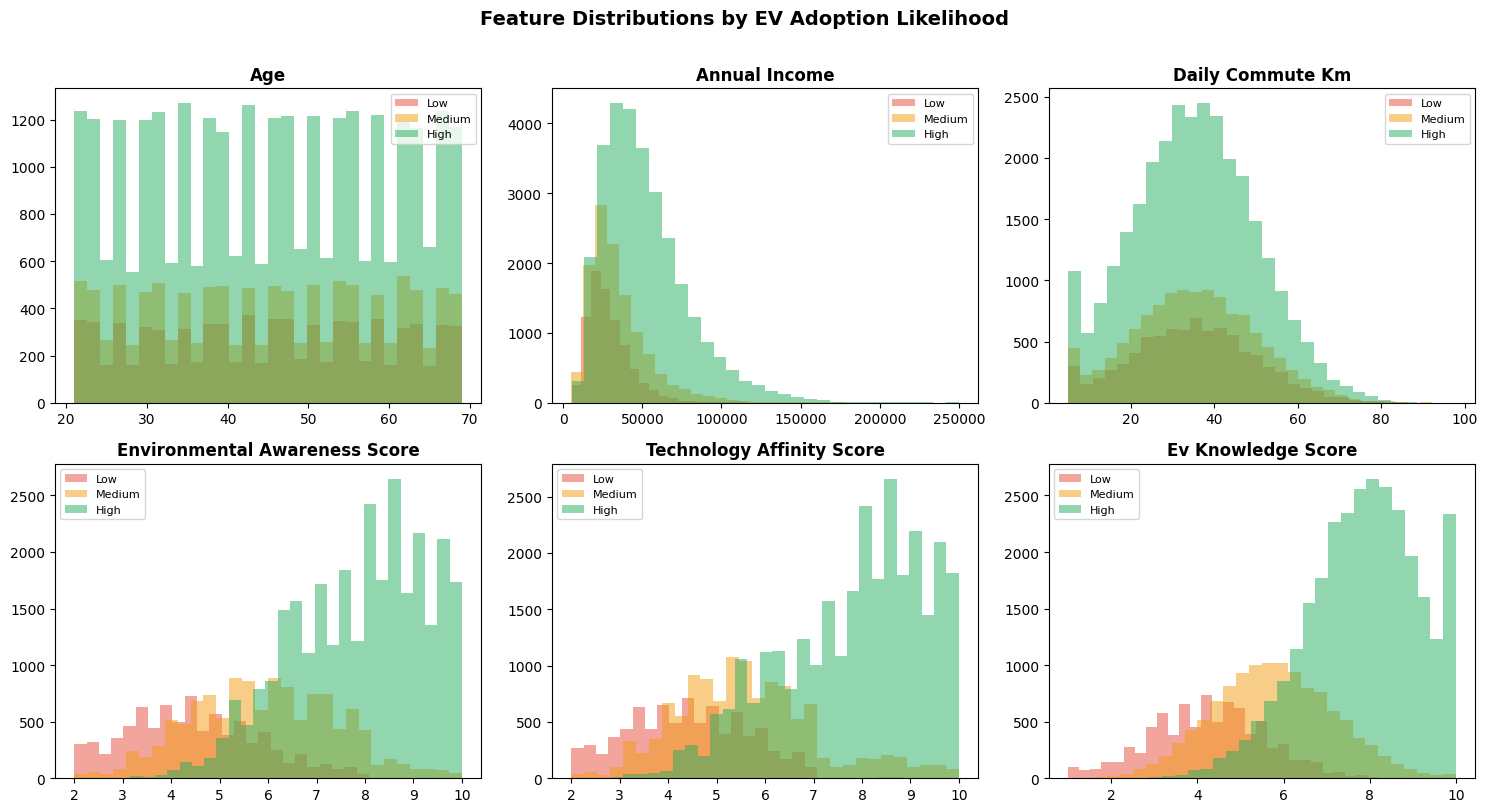

In [ ]:
# Fordeling af numeriske nøgle variable
num_features = ['age', 'annual_income', 'daily_commute_km', 
                'environmental_awareness_score', 'technology_affinity_score', 'ev_knowledge_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for label, color in zip(order, colors):
        subset = df[df['ev_adoption_likelihood'] == label][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.5, label=label, color=color)
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution af Features efter EV Adoption Sandlynlighed', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

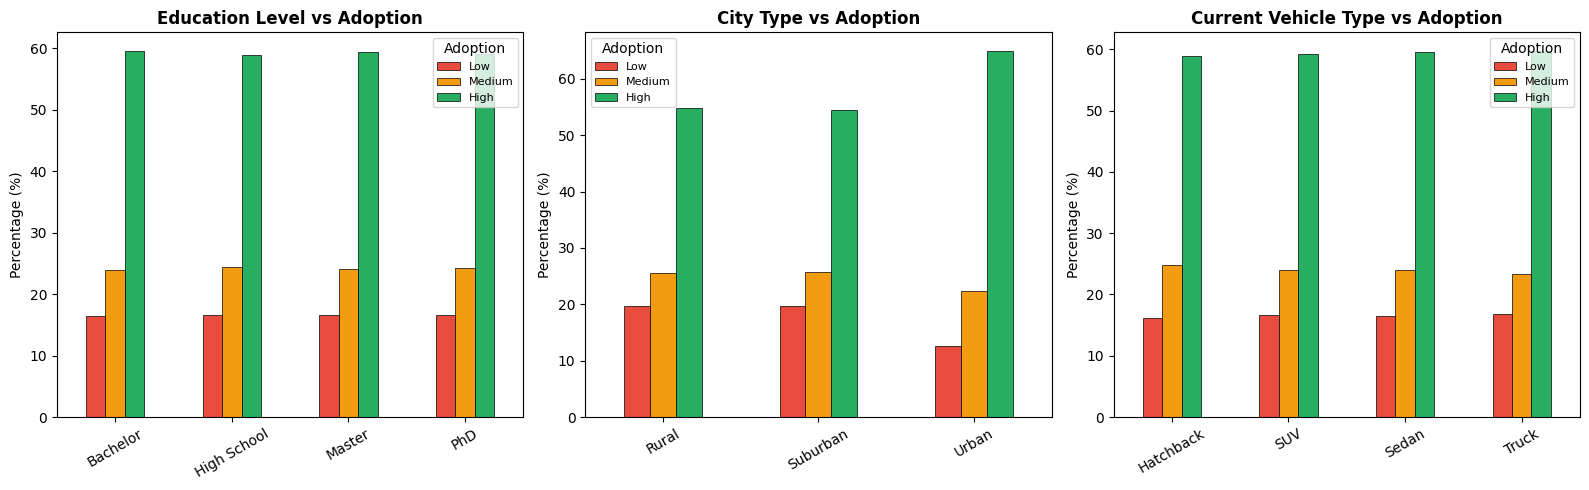

In [ ]:
# Analyse af kategoriske variable
cat_cols = ['education_level', 'city_type', 'current_vehicle_type']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['ev_adoption_likelihood'], normalize='index')[order] * 100
    ct.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{col.replace("_", " ").title()} vs Adoption', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='Adoption', fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

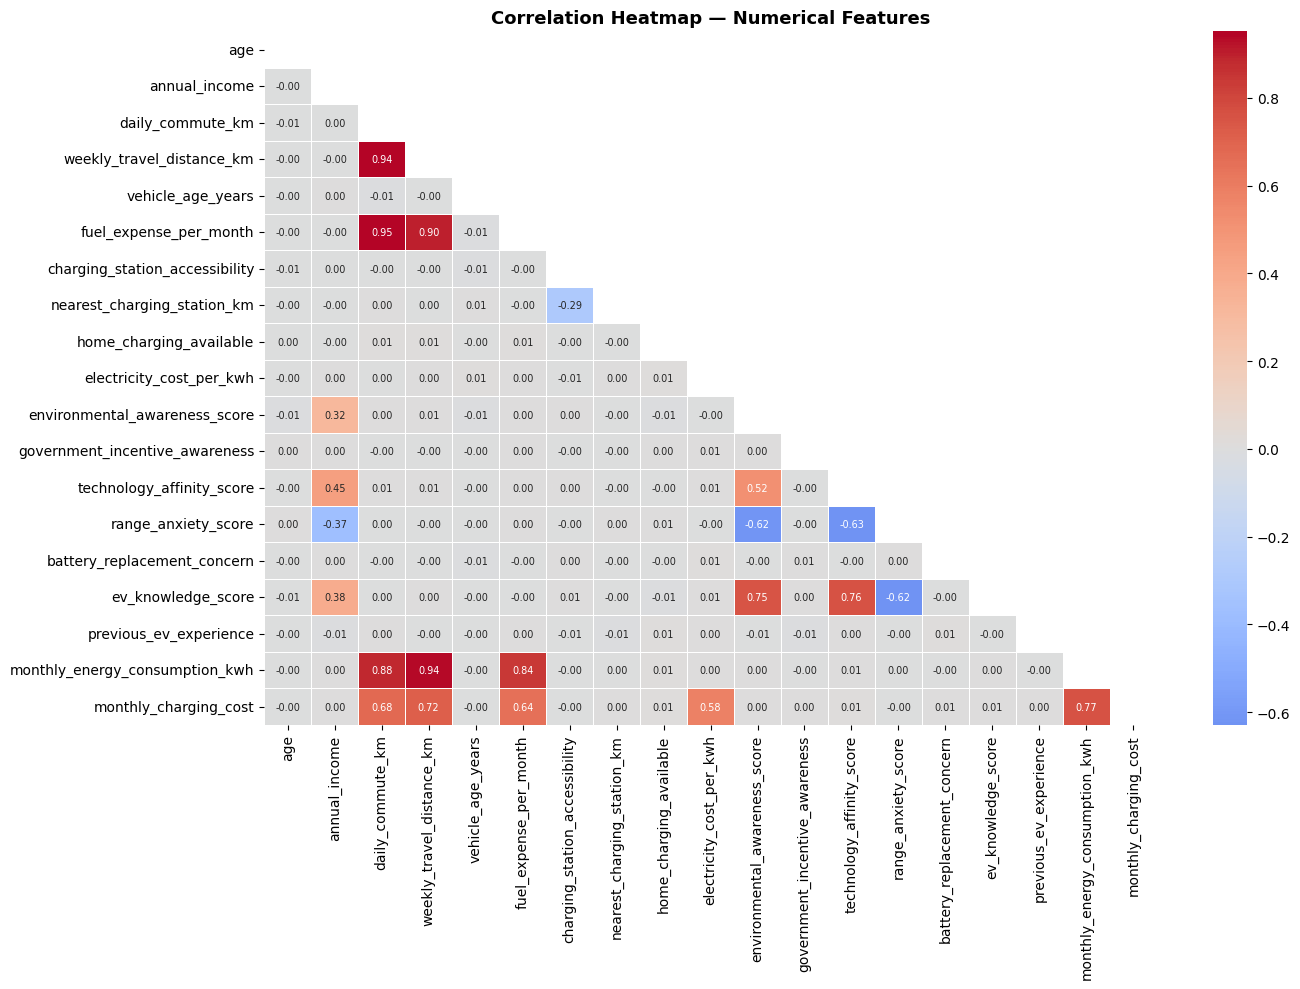

In [ ]:
# Korrelation Heatmap for numeriske variable
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## **🛠️ Step 4: Data Preprocessing**

Her gør vi følgende:
- Håndterer missing værdier (missing numeriske værdier udfyldes med median, kategoriske fyldes med mode)
- Omkoder kategoriske kolonner (konverter tekst -> numeriske værdier)
- Kontrollerer for datalækage – kolonner, der direkte afslører målvariablen, skal fjernes

> ⚠️ **Advarsel om Datalækage:** `monthly_energy_consumption_kwh` og `monthly_charging_cost` kan først eksistere, efter at en person har anskaffet sig en elbil. Vi fjerner derfor disse variable for at undgå en kunstigt høj modelnøjagtighed.

In [10]:
# Drop leakage columns
leakage_cols = ['monthly_energy_consumption_kwh', 'monthly_charging_cost']
df = df.drop(columns=leakage_cols)
print(f'✅ Dropped leakage columns: {leakage_cols}')
print(f'   Remaining columns: {df.shape[1]}')

✅ Dropped leakage columns: ['monthly_energy_consumption_kwh', 'monthly_charging_cost']
   Remaining columns: 21


In [11]:
# Fill missing values
cat_cols = ['education_level', 'city_type', 'current_vehicle_type']
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Numerical: fill with median (robust to outliers)
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical: fill with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f'✅ Missing values remaining: {df.isnull().sum().sum()}')

✅ Missing values remaining: 0


In [ ]:
# Omkoder kategoriske features via Label Encoding
# Label Encoding konvertere kategorier til integers: e.g., Rural=0, Suburban=1, Urban=2

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f'  {col}: encoded')

# Encode target variable: Low=1, Medium=2, High=0  (alphabetical by default)
# We use a manual map to keep it intuitive: Low=0, Medium=1, High=2
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['ev_adoption_likelihood'] = df['ev_adoption_likelihood'].map(target_map)
print('\n✅ Target encoded:', target_map)

  education_level: encoded
  city_type: encoded
  current_vehicle_type: encoded

✅ Target encoded: {'Low': 0, 'Medium': 1, 'High': 2}


## **✂️ Step 5: Train-Test Split**

Vi splitter vores data således at:
- **80% Træning** — hvad modellen bruger til at lære
- **20% Testning** — evaluere modellen med uset data

In [13]:
X = df.drop(columns=['ev_adoption_likelihood'])
y = df['ev_adoption_likelihood']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train size: {X_train.shape[0]:,} rows')
print(f'✅ Test  size: {X_test.shape[0]:,} rows')
print(f'✅ Features  : {X_train.shape[1]}')

✅ Train size: 40,000 rows
✅ Test  size: 10,000 rows
✅ Features  : 20


## **🤖 Step 6: Model Træning**

Vi træner **to modeller** og udvælger den bedste af de to:
1. **Random Forest** — an ensemble of beslutningstræer, der vil være en god baseline-model
2. **XGBoost** — gradient boosting, hvilket ofte giver de bedste resultater

In [14]:
# Model 1: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1               # use all CPU cores
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f'🌲 Random Forest Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)')

🌲 Random Forest Accuracy: 0.8475 (84.75%)


In [15]:
# Model 2: XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f'⚡ XGBoost Accuracy: {xgb_acc:.4f} ({xgb_acc*100:.2f}%)')

⚡ XGBoost Accuracy: 0.8700 (87.00%)


In [ ]:
# Vælger den bedste model
if xgb_acc >= rf_acc:
    best_model = xgb_model
    best_preds = xgb_preds
    best_name = 'XGBoost'
    best_acc = xgb_acc
else:
    best_model = rf_model
    best_preds = rf_preds
    best_name = 'Random Forest'
    best_acc = rf_acc

print(f'\n🏆 Best Model: {best_name} — Accuracy: {best_acc*100:.2f}%')


🏆 Best Model: XGBoost — Accuracy: 87.00%


## **📈 Step 7: Model Evaluering**

We use:
- **Accuracy** — antallet af korrekte forudsigelser (%)
- **Klassifikationsrapport** — nøjagtighed, recall, F1 per klasse
- **Confusion Matrix** — viser, hvilke klasser modellen forveksler
- **Krydsvalidering** — tester, om modellens score er stabil på tværs af forskellige data splits

In [ ]:
# Klassifikationsrapport
print(f'📊 Klassifikationsrapport — {best_name}')
print('='*55)
print(classification_report(y_test, best_preds,
                             target_names=['Low', 'Medium', 'High']))

📊 Classification Report — XGBoost
              precision    recall  f1-score   support

         Low       0.86      0.80      0.83      1650
      Medium       0.72      0.75      0.74      2416
        High       0.93      0.94      0.94      5934

    accuracy                           0.87     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.87      0.87      0.87     10000



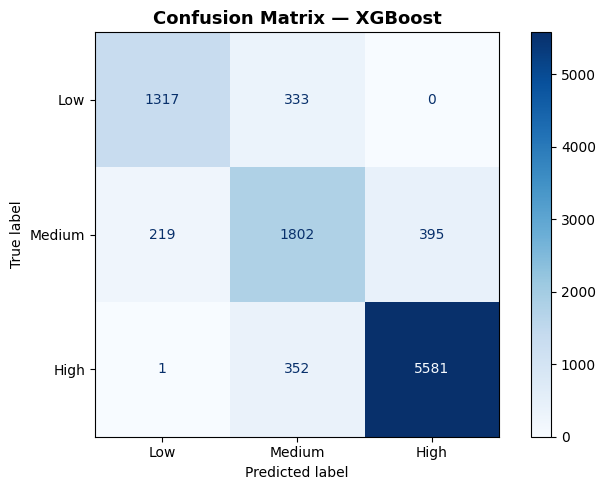

In [18]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Krydsvalidering (5-fold) — verificere model stabilitet
print('🔄 Running 5-Fold Cross-Validation...')
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'  CV Scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'  Mean CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

🔄 Running 5-Fold Cross-Validation...
  CV Scores: ['0.8676', '0.8689', '0.8605', '0.8703', '0.8647']
  Mean CV Accuracy: 0.8664 ± 0.0035


## **🎯 Step 8: Feature Importance**

Feature importance viser, hvilke features der har størst betydning for forudsigelsen af EV-adoption.

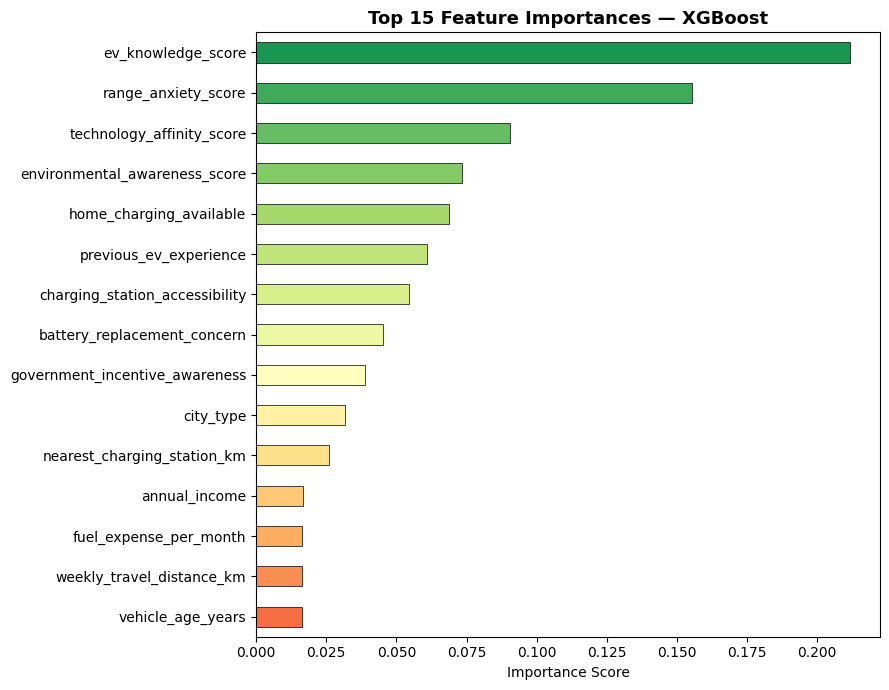

In [20]:
# Feature Importance Plot
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# Top 15
top15 = feat_imp.tail(15)

fig, ax = plt.subplots(figsize=(9, 7))
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top15)))
top15.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.set_title(f'Top 15 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## **✅ Konklusion**

### **Resume**

| Model | Test Nøjagtighed |
|---|---|
| Random Forest | 84.75% |
| **XGBoost (Bedst)** | **87.00%** |

### **Nøgleresultater**

1. **EV Knowledge Score, Technology Affinity og Environmental Awareness** er de mest betydelige variable for EV-adoption. Personer med høj viden om og interesse for elbiler har større sandsynlighed for adoption.

2. **Range Anxiety Score** har en betydelig negativ effekt. Jo større bekymring for at løbe tør for strøm, desto lavere sandsynlighed for adoption.

3. **Annual Income og Charging Station Accessibility** spiller en vigtig rolle i forhold til infrastruktur. Højere indkomst og nemmere adgang til ladestandere korrelerer med højere adoption.

4. **City Type** Personer i byområder har højere sandlynlighed for adoption end personer i landdistrikter, sandsynligvis grundet adgang til bedre infrastruktur.

5. **Government Incentive Awareness** intiativer er ikke tilstrækkelig af sig selv, men skal kombineres med god infrastruktur og lav **range anxiety**.

### **Mulige forbedringer**
- Test LightGBM eller CatBoost
- Udfør hyperparameter tuning med Optuna
- Tilføj SHAP-værdier for bedre forklarlighed
